# 급수

부분합 $S_n = \sum_{k=1}^{n} a_k$, 무한급수 $\sum_{k=1}^{\infty} a_k = \lim_{n\to\infty} S_n$.

$$
\sum_{k=0}^{\infty} ar^k = \frac{a}{1-r}\quad (|r|<1)
$$

| 급수 | 수렴 조건 | 합 |
|------|-----------|-----|
| 등비급수 $\sum ar^k$ | $|r|<1$ | $a/(1-r)$ |
| 등비급수 | $|r|\ge 1$ | 발산 |
| 등차급수 ($d\neq 0$) | — | 항상 발산 |


## 1. 부분합과 무한급수


일반항:


부분합:


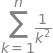

무한급수 합:


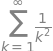

In [4]:
import sympy as sp
sp.init_printing()

n, k = sp.symbols('n k', integer=True, positive=True)

# 예: a_k = 1/k^2 (p-급수, p=2 → 수렴)
a_k = 1 / k**2
S_n = sp.Sum(a_k, (k, 1, n))
S_closed = sp.summation(a_k, (k, 1, n))
S_inf = sp.Sum(a_k, (k, 1, sp.oo))

print("일반항:")
display(a_k)
print("부분합:")
display(S_n)
display(S_closed)
print("무한급수 합:")
display(S_inf)
display(S_inf.doit())


**sp.Sum(expr, (k, 1, n))**: <br>
=> 급수 기호 표현 (아직 계산하지 않음)

**sp.summation(expr, (k, 1, n))** / **Sum.doit()**: <br>
=> 닫힌 형태(또는 값)로 계산


## 2. 등비급수 — 부분합과 합 공식

$$
S_n = a\frac{1-r^n}{1-r}\ (r\neq 1),\qquad
S = \lim_{n\to\infty} S_n = \frac{a}{1-r}\ (|r|<1)
$$


In [5]:
a, r = sp.symbols('a r', real=True)
a_k = a * r**(k - 1)  # 첫항 a, 공비 r (k=1부터)

S_n = sp.summation(a_k, (k, 1, n))
print("등비급수 부분합 S_n:")
display(S_n)
display(sp.simplify(S_n))

# 구체: a=1, r=1/2
vals = {a: 1, r: sp.Rational(1, 2)}
S_n_num = sp.simplify(S_n.subs(vals))
S_inf = sp.limit(S_n_num, n, sp.oo)

print("a=1, r=1/2:")
display(S_n_num)
print(f"무한합 S = {S_inf}  (= a/(1-r) = 2)")


등비급수 부분합 S_n:


  ⎛⎧    n                ⎞
  ⎜⎪    ─       for r = 1⎟
  ⎜⎪    r                ⎟
  ⎜⎪                     ⎟
a⋅⎜⎨     n + 1           ⎟
  ⎜⎪r - r                ⎟
  ⎜⎪──────────  otherwise⎟
  ⎜⎪r⋅(1 - r)            ⎟
  ⎝⎩                     ⎠

⎧   a⋅n      for r = 1
⎪                     
⎪  ⎛ n    ⎞           
⎨a⋅⎝r  - 1⎠           
⎪──────────  otherwise
⎪  r - 1              
⎩                     

a=1, r=1/2:


무한합 S = 2  (= a/(1-r) = 2)


## 3. 수렴 조건 $|r|<1$ — 여러 공비 비교


In [6]:
from sympy.series.limitseq import limit_seq

a_val = 1
r_list = [
    sp.Rational(1, 2),
    sp.Rational(-1, 3),
    1,
    -1,
    2,
]

for r_val in r_list:
    a_k = a_val * r_val**(k - 1)
    S_n = sp.simplify(sp.summation(a_k, (k, 1, n)))
    # r<0 이면 S_n 에 (-1)^n 이 들어가 sp.limit 실패 → limit_seq
    try:
        S = sp.limit(S_n, n, sp.oo)
    except NotImplementedError:
        S = limit_seq(S_n, n)

    cond = abs(r_val) < 1
    print("=" * 40)
    print(f"r = {r_val}, |r|<1? {cond}")
    print(f"S_n = {S_n}")
    print(f"lim S_n = {S}")
    if isinstance(S, sp.AccumBounds):
        print("  → 부분합 진동, 급수 발산")
    elif cond:
        formula = a_val / (1 - r_val)
        print(f"공식 a/(1-r) = {formula}")


r = 1/2, |r|<1? True
S_n = 2 - 2/2**n
lim S_n = 2
공식 a/(1-r) = 2
r = -1/3, |r|<1? True
S_n = -3*(-1)**n/(4*3**n) + 3/4
lim S_n = 3/4
공식 a/(1-r) = 3/4
r = 1, |r|<1? False
S_n = n
lim S_n = oo
r = -1, |r|<1? False
S_n = 1/2 - (-1)**n/2
lim S_n = AccumBounds(0, 1)
  → 부분합 진동, 급수 발산
r = 2, |r|<1? False
S_n = 2**n - 1
lim S_n = oo


**판정 요약**:

- $|r|<1$ → 수렴, 합 $a/(1-r)$
- $|r|>1$ → 발산
- $r=1$ → $S_n = na$ 발산 ($a\neq 0$)
- $r=-1$ → 부분합 진동, 발산

**주의**: <br>
=> $r<0$ 이면 $S_n$에 $(-1)^n$이 들어가 `sp.limit`이 `NotImplementedError`를 낼 수 있음 <br>
=> `limit_seq`로 넘기면 $|r|<1$일 때 올바른 합, $r=-1$이면 `AccumBounds`(진동)가 나옴


## 4. 등차급수는 발산


In [7]:
# 등차: a_k = a1 + (k-1)d
a1, d = 2, 3
a_k = a1 + (k - 1)*d

S_n = sp.simplify(sp.summation(a_k, (k, 1, n)))
S_inf = sp.limit(S_n, n, sp.oo)

print("일반항 (등차):")
display(a_k)
print("부분합:")
display(S_n)
print(f"lim(n→∞) S_n = {S_inf}  → 발산 (d≠0)")
print(f"S_9 = {S_n.subs(n, 9)}")


일반항 (등차):


부분합:


lim(n→∞) S_n = oo  → 발산 (d≠0)
S_9 = 126


## 5. `sp.Sum(...).doit()` 로 무한등비급수


급수:


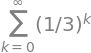

합:


공식 1/(1-r) = 3/2
Σ 2^k:


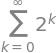

In [8]:
r = sp.Rational(1, 3)
series = sp.Sum(r**k, (k, 0, sp.oo))  # Σ r^k from k=0

print("급수:")
display(series)
print("합:")
display(series.doit())
print(f"공식 1/(1-r) = {1/(1-r)}")

# |r|≥1 이면 발산
bad = sp.Sum(2**k, (k, 0, sp.oo))
print("Σ 2^k:")
display(bad)
display(bad.doit())  # 발산 표현
